In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Skip the 32-line text header
df = pd.read_csv(
    '../datasets_raw/uurgeg_209_2011-2020.txt',
    skiprows=31,
    header=0,
    na_values=['     ', '   ', '  ', ' ', ''],
)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

print(df.shape)
print(df.head())
print(df.dtypes)

(87672, 25)
   # STN  YYYYMMDD  HH     DD    FH    FF    FX   T  T10N  TD  ...  VV   N  \
0    209  20110101   1  260.0  70.0  80.0  90.0 NaN   NaN NaN  ... NaN NaN   
1    209  20110101   2  270.0  70.0  70.0  90.0 NaN   NaN NaN  ... NaN NaN   
2    209  20110101   3  260.0  80.0  70.0  90.0 NaN   NaN NaN  ... NaN NaN   
3    209  20110101   4  260.0  70.0  70.0  90.0 NaN   NaN NaN  ... NaN NaN   
4    209  20110101   5  270.0  70.0  70.0  80.0 NaN   NaN NaN  ... NaN NaN   

    U  WW  IX   M   R   S   O   Y  
0 NaN NaN   6 NaN NaN NaN NaN NaN  
1 NaN NaN   6 NaN NaN NaN NaN NaN  
2 NaN NaN   6 NaN NaN NaN NaN NaN  
3 NaN NaN   6 NaN NaN NaN NaN NaN  
4 NaN NaN   6 NaN NaN NaN NaN NaN  

[5 rows x 25 columns]
# STN         int64
YYYYMMDD      int64
HH            int64
DD          float64
FH          float64
FF          float64
FX          float64
T           float64
T10N        float64
TD          float64
SQ          float64
Q           float64
DR          float64
RH          float64


In [4]:
# KNMI HH uses 1-24 (hour 24 = end of day = midnight next day)
# Convert HH=24 next day HH=0 before parsing
df['HH_fixed'] = df['HH'].astype(int)
overflow = df['HH_fixed'] == 24
df.loc[overflow, 'HH_fixed'] = 0

# Build datetime string and parse
df['datetime_str'] = df['YYYYMMDD'].astype(str) + df['HH_fixed'].astype(str).str.zfill(2)
df['timestamp'] = pd.to_datetime(df['datetime_str'], format='%Y%m%d%H')

# Add 1 day where HH was 24
df.loc[overflow, 'timestamp'] = df.loc[overflow, 'timestamp'] + pd.Timedelta(days=1)

# Localise to CET (KNMI data is in UT/UTC, so shift +1h)
df['timestamp'] = df['timestamp'] + pd.Timedelta(hours=1)
df = df.set_index('timestamp').sort_index()

print("Time range:", df.index.min(), "→", df.index.max())
print("Total rows:", len(df))

Time range: 2011-01-01 02:00:00 → 2021-01-01 01:00:00
Total rows: 87672


In [5]:
# Keep only wind-relevant and pressure columns
cols = {
    'STN': 'station',
    'DD': 'wind_direction_deg',
    'FH': 'wind_speed_ms',
    'FF': 'wind_speed_10min_ms',
    'FX': 'wind_gust_ms',
    'T':  'temperature_c',
    'P':  'pressure_hpa',
    'U':  'humidity_pct',
    'RH': 'precipitation_mm',
}
df = df.rename(columns=cols)[[c for c in cols.values() if c in df.rename(columns=cols).columns]]

# Convert from 0.1 units to real units
for col in ['wind_speed_ms', 'wind_speed_10min_ms', 'wind_gust_ms']:
    df[col] = df[col] / 10.0

df['temperature_c'] = df['temperature_c'] / 10.0
df['pressure_hpa']  = df['pressure_hpa']  / 10.0
df['precipitation_mm'] = df['precipitation_mm'] / 10.0

# Replace -1 precipitation sentinel with 0.025
df['precipitation_mm'] = df['precipitation_mm'].replace(-0.1, 0.025)

print(df.describe())

       wind_direction_deg  wind_speed_ms  wind_speed_10min_ms  wind_gust_ms  \
count        85404.000000   85400.000000         85405.000000  85400.000000   
mean           197.748583       7.328173             7.331667      9.712131   
std             96.640094       3.513878             3.556342      4.510725   
min              0.000000       0.000000             0.000000      0.000000   
25%            120.000000       5.000000             5.000000      6.000000   
50%            210.000000       7.000000             7.000000      9.000000   
75%            270.000000       9.000000             9.000000     12.000000   
max            990.000000      26.000000            27.000000     36.000000   

       temperature_c  pressure_hpa  humidity_pct  precipitation_mm  
count            0.0           0.0           0.0               0.0  
mean             NaN           NaN           NaN               NaN  
std              NaN           NaN           NaN               NaN  
min         

In [6]:
# Full hourly index to detect gaps
full_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
missing_hours = full_index.difference(df.index)
print(f"Expected hours: {len(full_index)}")
print(f"Actual rows:    {len(df)}")
print(f"Missing timestamps: {len(missing_hours)}")

# Missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nMissing % wind_speed_ms: {df['wind_speed_ms'].isnull().mean()*100:.2f}%")

Expected hours: 87672
Actual rows:    87672
Missing timestamps: 0

Missing values per column:
wind_direction_deg      2268
wind_speed_ms           2272
wind_speed_10min_ms     2267
wind_gust_ms            2272
temperature_c          87672
pressure_hpa           87672
humidity_pct           87672
precipitation_mm       87672
dtype: int64

Missing % wind_speed_ms: 2.59%


In [7]:
# Wind speed physical limits: 0–50 m/s
ws_outliers = df[(df['wind_speed_ms'] < 0) | (df['wind_speed_ms'] > 50)]
print(f"Wind speed outliers: {len(ws_outliers)}")
df.loc[df['wind_speed_ms'] > 50, 'wind_speed_ms'] = np.nan
df.loc[df['wind_speed_ms'] < 0,  'wind_speed_ms'] = np.nan

# Wind direction: valid 0–360
df.loc[df['wind_direction_deg'] > 360,  'wind_direction_deg'] = np.nan

# IQR outlier flag for wind speed (for documentation)
Q1 = df['wind_speed_ms'].quantile(0.25)
Q3 = df['wind_speed_ms'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = df[(df['wind_speed_ms'] < Q1 - 3*IQR) | (df['wind_speed_ms'] > Q3 + 3*IQR)]
print(f"IQR outliers (3x) in wind speed: {len(iqr_outliers)}")

Wind speed outliers: 0
IQR outliers (3x) in wind speed: 29


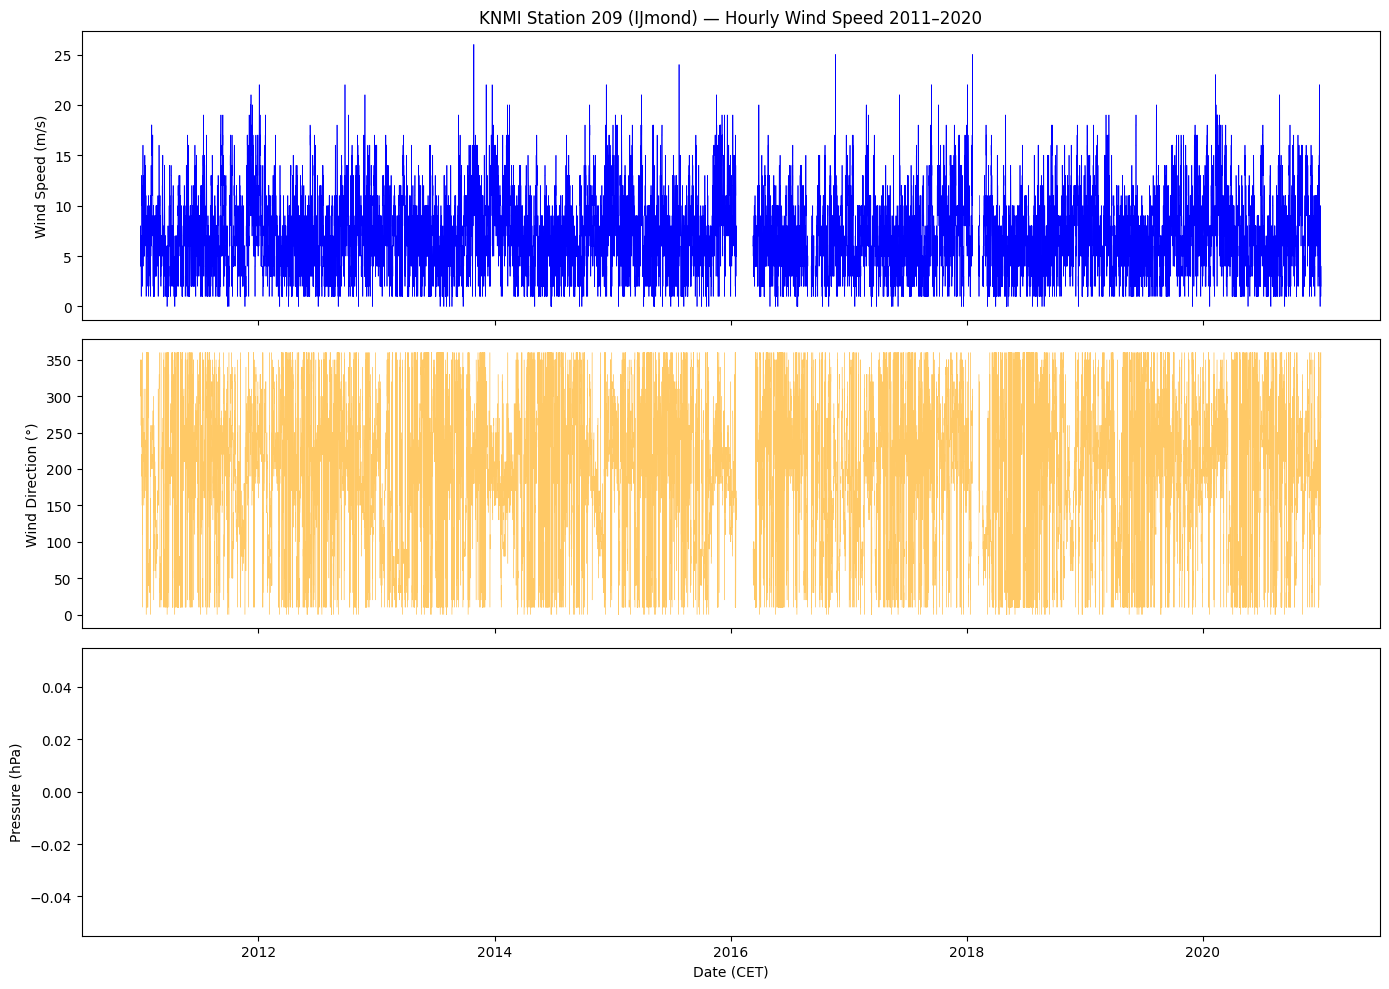

Plot saved.


In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df.index, df['wind_speed_ms'], linewidth=0.5, color='blue')
axes[0].set_ylabel('Wind Speed (m/s)')
axes[0].set_title('KNMI Station 209 (IJmond) — Hourly Wind Speed 2011–2020')

axes[1].plot(df.index, df['wind_direction_deg'], linewidth=0.3, color='orange', alpha=0.6)
axes[1].set_ylabel('Wind Direction (°)')

axes[2].plot(df.index, df['pressure_hpa'], linewidth=0.4, color='green', alpha=0.7)
axes[2].set_ylabel('Pressure (hPa)')
axes[2].set_xlabel('Date (CET)')

plt.tight_layout()
plt.show()

In [10]:
df_clean = df.dropna(subset=['wind_speed_ms'])  # require wind speed to be present
df_clean.to_csv('../datasets/knmi_209_2011_2020_cleaned.csv')

print(f"Raw rows:     {len(df)}")
print(f"Cleaned rows: {len(df_clean)}")
print(f"Dropped:      {len(df) - len(df_clean)}")
print("Saved: knmi_209_2011_2020_cleaned.csv")

Raw rows:     87672
Cleaned rows: 85400
Dropped:      2272
Saved: knmi_209_2011_2020_cleaned.csv
